# ControlCorePy
## Núcleo fundacional para análisis y diseño de control en Python / Colab

**Propósito:** construir un núcleo computacional propio, extensible y pedagógicamente transparente, inspirado en la lógica de MATLAB/Octave para análisis de sistemas de control.

Este notebook contiene:

- razón de ser del proyecto;
- arquitectura conceptual;
- mini-framework `ControlCorePy`;
- representación por función de transferencia `TF`;
- representación por espacio de estados `SS`;
- análisis de polos, ceros y estabilidad;
- respuestas temporales;
- análisis frecuencial;
- Bode;
- Nyquist;
- márgenes aproximados;
- root locus;
- discretización;
- controlabilidad;
- observabilidad;
- compensadores;
- ejemplos completos;
- guía de crecimiento futuro.

La intención no es competir inmediatamente con MATLAB, Octave o `python-control`, sino crear un **core semilla** serio para estudiar, extender y comprender desde adentro cómo se construye una herramienta de control.

## Índice

1. Prólogo técnico
2. Razón de ser
3. Criterios de diseño del core
4. Arquitectura propuesta
5. Dependencias numéricas
6. Implementación de `ControlCorePy`
7. Manual de uso rápido
8. Fundamentos matemáticos internos
9. Ejemplo 1: planta de primer orden
10. Ejemplo 2: segundo orden subamortiguado
11. Ejemplo 3: función de transferencia y lazo cerrado
12. Ejemplo 4: espacio de estados
13. Ejemplo 5: controlabilidad y observabilidad
14. Ejemplo 6: Bode, Nyquist y márgenes
15. Ejemplo 7: root locus
16. Ejemplo 8: compensador de adelanto
17. Ejemplo 9: compensador de atraso
18. Ejemplo 10: compensador adelanto-atraso
19. Ejemplo 11: discretización
20. Pruebas internas mínimas
21. Hoja de ruta para hacerlo crecer
22. Conclusión

# 1. Prólogo técnico

El objetivo de este notebook es construir una base propia para análisis y diseño de control.

La motivación nace de una pregunta muy importante:

> Si MATLAB, Octave y Simulink se apoyan en álgebra lineal numérica, representación de sistemas, solvers, factorizaciones y rutinas robustas, ¿qué tan lejos podemos llegar construyendo un core propio en Python?

La respuesta honesta es:

- podemos llegar muy lejos conceptualmente;
- podemos apoyarnos en `NumPy` y `SciPy`, que por debajo utilizan rutinas numéricas maduras;
- podemos construir una capa pedagógica y extensible;
- debemos ser conscientes de los límites numéricos de una implementación inicial.

Este notebook busca ser un **punto de partida digno**, no una caja negra.

# 2. Razón de ser

La idea central es separar dos niveles:

## Nivel matemático

La teoría de control clásico y moderno utiliza:

$$
G(s)=\frac{Y(s)}{X(s)}
$$

$$
\dot{x}=Ax+Bu
$$

$$
y=Cx+Du
$$

$$
T(s)=\frac{G(s)}{1+G(s)}
$$

$$
D(s)+KN(s)=0
$$

## Nivel computacional

Una herramienta de control necesita representar, transformar, analizar y simular estos objetos.

Por eso el core debe permitir:

- crear sistemas;
- operar sistemas;
- convertir representaciones;
- simular respuestas;
- analizar estabilidad;
- analizar frecuencia;
- diseñar compensadores;
- comparar resultados.

# 3. Criterios de diseño del core

## Transparencia

El usuario debe poder leer el código y entender qué ocurre.

## Representación dual

Se implementan dos representaciones:

- `TF`: función de transferencia.
- `SS`: espacio de estados.

La función de transferencia es excelente para control clásico. El espacio de estados es más adecuado para control moderno y robustez numérica.

## Uso de bases numéricas maduras

El core usa:

- `numpy`;
- `scipy.signal`;
- `scipy.linalg`;
- `matplotlib`.

## Extensibilidad

La librería se escribe como una semilla. Debe poder crecer hacia MIMO, identificación, control robusto, LQR, Kalman, MPC, simulación híbrida, exportación de modelos e interfaz gráfica.

# 4. Arquitectura propuesta

```text
ControlCorePy
│
├── TF
│   ├── num, den
│   ├── polos, ceros
│   ├── operaciones algebraicas
│   ├── respuesta temporal
│   ├── respuesta frecuencial
│   └── conversión a SS
│
├── SS
│   ├── A, B, C, D
│   ├── polos
│   ├── controlabilidad
│   ├── observabilidad
│   ├── respuesta temporal
│   ├── discretización
│   └── conversión a TF
│
├── Analysis
│   ├── bode
│   ├── nyquist
│   ├── root locus
│   ├── márgenes
│   └── step info
│
├── Design
│   ├── lead
│   ├── lag
│   ├── lead-lag
│   └── feedback
│
└── Utilities
    ├── normalización
    ├── trimming
    ├── validaciones
    └── tests mínimos
```

# 5. Dependencias numéricas

Este core se apoya en librerías científicas estándar:

- `NumPy`: arrays, polinomios, raíces, operaciones vectorizadas.
- `SciPy.signal`: modelos LTI, simulación, conversión TF/SS, discretización.
- `SciPy.linalg`: álgebra lineal robusta.
- `Matplotlib`: visualización.

> Nota importante: Python actúa como capa expresiva. El cálculo pesado de NumPy/SciPy suele delegarse a rutinas compiladas en C, C++ y Fortran.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, linalg
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 6. Implementación de `ControlCorePy`

La siguiente celda define el núcleo: `TF`, `SS`, lazo cerrado, respuestas temporales, Bode, Nyquist, root locus, márgenes, discretización, controlabilidad, observabilidad y compensadores.

In [2]:
# ============================================================
# ControlCorePy - núcleo fundacional para control en Python
# ============================================================
EPS = 1e-12


def _as_1d_float_array(x):
    return np.asarray(x, dtype=float).flatten()


def _trim_poly(p, tol=1e-12):
    p = _as_1d_float_array(p)
    if len(p) == 0:
        return np.array([0.0])
    idx = np.where(np.abs(p) > tol)[0]
    if len(idx) == 0:
        return np.array([0.0])
    return p[idx[0]:]


def _normalize_tf(num, den):
    num = _trim_poly(num)
    den = _trim_poly(den)
    if len(den) == 1 and abs(den[0]) < EPS:
        raise ValueError("Denominador nulo.")
    if abs(den[0]) < EPS:
        raise ValueError("El primer coeficiente del denominador no puede ser cero.")
    num = num / den[0]
    den = den / den[0]
    return num, den


def _poly_to_str(p):
    return str(np.poly1d(p))


def _is_stable_continuous(poles):
    return np.all(np.real(poles) < 0)


def _is_stable_discrete(poles):
    return np.all(np.abs(poles) < 1)


class TF:
    """Funcion de transferencia continua o discreta SISO."""
    def __init__(self, num, den, name="G", dt=None):
        self.num, self.den = _normalize_tf(num, den)
        self.name = name
        self.dt = dt

    @property
    def is_discrete(self):
        return self.dt is not None

    @property
    def is_continuous(self):
        return self.dt is None

    def __repr__(self):
        domain = "z" if self.is_discrete else "s"
        return f"{self.name}({domain}) = ({_poly_to_str(self.num)}) / ({_poly_to_str(self.den)})"

    def scipy(self):
        if self.is_discrete:
            return signal.dlti(self.num, self.den, dt=self.dt)
        return signal.TransferFunction(self.num, self.den)

    def poles(self):
        return np.roots(self.den)

    def zeros(self):
        if len(self.num) == 1 and abs(self.num[0]) < EPS:
            return np.array([])
        return np.roots(self.num)

    def gain(self):
        point = 1 if self.is_discrete else 0
        denv = np.polyval(self.den, point)
        if abs(denv) < EPS:
            return np.inf
        return np.polyval(self.num, point) / denv

    def eval(self, x):
        return np.polyval(self.num, x) / np.polyval(self.den, x)

    def is_stable(self):
        p = self.poles()
        return _is_stable_discrete(p) if self.is_discrete else _is_stable_continuous(p)

    def minreal(self, tol=1e-7):
        """Cancelacion polo-cero aproximada. Pedagogica, no profesional."""
        z = list(self.zeros())
        p = list(self.poles())
        used_p = set()
        z_keep = []
        for zi in z:
            distances = [abs(zi - pj) if j not in used_p else np.inf for j, pj in enumerate(p)]
            jmin = int(np.argmin(distances)) if len(distances) else -1
            if jmin >= 0 and distances[jmin] < tol:
                used_p.add(jmin)
            else:
                z_keep.append(zi)
        p_keep = [pj for j, pj in enumerate(p) if j not in used_p]
        k = self.num[0] / self.den[0]
        num_new = k*np.poly(z_keep) if len(z_keep) else np.array([k])
        den_new = np.poly(p_keep) if len(p_keep) else np.array([1.0])
        return TF(np.real_if_close(num_new), np.real_if_close(den_new), name=self.name+"_min", dt=self.dt)

    def to_ss(self, name=None):
        A, B, C, D = signal.tf2ss(self.num, self.den)
        return SS(A, B, C, D, name=name or self.name+"_ss", dt=self.dt)

    def step(self, t_end=10, n=1000):
        if self.is_discrete:
            n_samples = int(n)
            tout, y = signal.dstep((self.num, self.den, self.dt), n=n_samples)
            return np.squeeze(tout)*self.dt, np.squeeze(y)
        t = np.linspace(0, t_end, n)
        tout, y = signal.step(self.scipy(), T=t)
        return tout, y

    def impulse(self, t_end=10, n=1000):
        if self.is_discrete:
            n_samples = int(n)
            tout, y = signal.dimpulse((self.num, self.den, self.dt), n=n_samples)
            return np.squeeze(tout)*self.dt, np.squeeze(y)
        t = np.linspace(0, t_end, n)
        tout, y = signal.impulse(self.scipy(), T=t)
        return tout, y

    def freqresp(self, w=None):
        if w is None:
            w = np.logspace(-3, 3, 2000)
        if self.is_discrete:
            z = np.exp(1j*w*self.dt)
            return w, self.eval(z)
        return w, self.eval(1j*w)

    def bode(self, w=None):
        w, H = self.freqresp(w)
        mag = 20*np.log10(np.maximum(np.abs(H), EPS))
        phase = np.unwrap(np.angle(H))*180/np.pi
        return w, mag, phase

    def __mul__(self, other):
        if isinstance(other, TF):
            if self.dt != other.dt:
                raise ValueError("No se pueden multiplicar sistemas con dt distinto.")
            return TF(np.polymul(self.num, other.num), np.polymul(self.den, other.den), name=f"({self.name}*{other.name})", dt=self.dt)
        return TF(self.num*other, self.den, name=f"{other}*{self.name}", dt=self.dt)

    def __rmul__(self, other):
        return self.__mul__(other)

    def __add__(self, other):
        if isinstance(other, TF):
            if self.dt != other.dt:
                raise ValueError("No se pueden sumar sistemas con dt distinto.")
            num = np.polyadd(np.polymul(self.num, other.den), np.polymul(other.num, self.den))
            den = np.polymul(self.den, other.den)
            return TF(num, den, name=f"({self.name}+{other.name})", dt=self.dt)
        return TF(np.polyadd(self.num, other*self.den), self.den, name=f"({self.name}+{other})", dt=self.dt)

    def __sub__(self, other):
        return self + (-1)*other

    def __truediv__(self, other):
        if isinstance(other, TF):
            if self.dt != other.dt:
                raise ValueError("No se pueden dividir sistemas con dt distinto.")
            return TF(np.polymul(self.num, other.den), np.polymul(self.den, other.num), name=f"({self.name}/{other.name})", dt=self.dt)
        return TF(self.num, self.den*other, name=f"({self.name}/{other})", dt=self.dt)


class SS:
    """Representacion en espacio de estados: xdot = Ax + Bu; y = Cx + Du."""
    def __init__(self, A, B, C, D, name="SS", dt=None):
        self.A = np.asarray(A, dtype=float)
        self.B = np.asarray(B, dtype=float)
        self.C = np.asarray(C, dtype=float)
        self.D = np.asarray(D, dtype=float)
        self.name = name
        self.dt = dt
        self._validate()

    def _validate(self):
        n = self.A.shape[0]
        if self.A.shape != (n, n):
            raise ValueError("A debe ser cuadrada.")
        if self.B.shape[0] != n:
            raise ValueError("B debe tener tantas filas como estados.")
        if self.C.shape[1] != n:
            raise ValueError("C debe tener tantas columnas como estados.")
        if self.D.shape != (self.C.shape[0], self.B.shape[1]):
            raise ValueError("D debe tener dimensiones salidas x entradas.")

    @property
    def is_discrete(self):
        return self.dt is not None

    def __repr__(self):
        kind = "discreto" if self.is_discrete else "continuo"
        return f"{self.name}: SS {kind}, n={self.A.shape[0]}, m={self.B.shape[1]}, p={self.C.shape[0]}"

    def poles(self):
        return np.linalg.eigvals(self.A)

    def is_stable(self):
        return _is_stable_discrete(self.poles()) if self.is_discrete else _is_stable_continuous(self.poles())

    def to_tf(self, input_index=0, output_index=0, name=None):
        num, den = signal.ss2tf(self.A, self.B, self.C, self.D, input=input_index)
        return TF(num[output_index], den, name=name or self.name+"_tf", dt=self.dt)

    def controllability_matrix(self):
        n = self.A.shape[0]
        return np.hstack([np.linalg.matrix_power(self.A, i) @ self.B for i in range(n)])

    def observability_matrix(self):
        n = self.A.shape[0]
        return np.vstack([self.C @ np.linalg.matrix_power(self.A, i) for i in range(n)])

    def controllability_rank(self, tol=None):
        return np.linalg.matrix_rank(self.controllability_matrix(), tol=tol)

    def observability_rank(self, tol=None):
        return np.linalg.matrix_rank(self.observability_matrix(), tol=tol)

    def is_controllable(self):
        return self.controllability_rank() == self.A.shape[0]

    def is_observable(self):
        return self.observability_rank() == self.A.shape[0]

    def gramian_controllability(self):
        if self.is_discrete:
            return linalg.solve_discrete_lyapunov(self.A, self.B @ self.B.T)
        return linalg.solve_continuous_lyapunov(self.A, -(self.B @ self.B.T))

    def gramian_observability(self):
        if self.is_discrete:
            return linalg.solve_discrete_lyapunov(self.A.T, self.C.T @ self.C)
        return linalg.solve_continuous_lyapunov(self.A.T, -(self.C.T @ self.C))

    def discretize(self, dt, method="zoh", name=None):
        Ad, Bd, Cd, Dd, dtd = signal.cont2discrete((self.A, self.B, self.C, self.D), dt=dt, method=method)
        return SS(Ad, Bd, Cd, Dd, name=name or self.name+"_d", dt=dtd)

    def step(self, t_end=10, n=1000):
        return self.to_tf(name=self.name+"_tf_tmp").step(t_end=t_end, n=n)

    def impulse(self, t_end=10, n=1000):
        return self.to_tf(name=self.name+"_tf_tmp").impulse(t_end=t_end, n=n)


def feedback(G, H=None, sign=-1, name="T"):
    if not isinstance(G, TF):
        raise TypeError("feedback actualmente trabaja con TF SISO.")
    if H is None:
        H = TF([1], [1], name="1", dt=G.dt)
    if G.dt != H.dt:
        raise ValueError("G y H deben tener el mismo dt.")
    GH = G*H
    den_cl = np.polyadd(GH.den, GH.num) if sign == -1 else np.polysub(GH.den, GH.num)
    num_cl = np.polymul(G.num, H.den)
    return TF(num_cl, den_cl, name=name, dt=G.dt)


def step_info(t, y, tolerance=0.02):
    y = np.asarray(y).flatten(); t = np.asarray(t).flatten()
    y_final = y[-1]; y_peak = np.max(y)
    overshoot = np.nan if abs(y_final) < EPS else max(0.0, (y_peak-y_final)/abs(y_final)*100)
    def first_cross(level):
        idx = np.where(y >= level)[0]
        return t[idx[0]] if len(idx) else np.nan
    if y_final >= 0:
        t10 = first_cross(0.1*y_final); t90 = first_cross(0.9*y_final)
    else:
        t10, t90 = np.nan, np.nan
    rise_time = t90-t10 if not np.isnan(t10) and not np.isnan(t90) else np.nan
    band = tolerance*max(abs(y_final), EPS)
    outside = np.where(np.abs(y-y_final) > band)[0]
    settling_time = t[outside[-1]+1] if len(outside) and outside[-1]+1 < len(t) else t[0]
    return {"valor_final": float(y_final), "valor_pico": float(y_peak), "sobrepico_%": float(overshoot), "tiempo_subida_10_90": float(rise_time), "tiempo_establecimiento": float(settling_time)}


def plot_step(sys, t_end=10, n=1000, label=None):
    t, y = sys.step(t_end=t_end, n=n)
    plt.figure(); plt.plot(t, y, label=label or sys.name)
    plt.title(f"Respuesta al escalon - {sys.name}"); plt.xlabel("Tiempo [s]"); plt.ylabel("Salida"); plt.legend(); plt.show()
    return t, y


def plot_impulse(sys, t_end=10, n=1000, label=None):
    t, y = sys.impulse(t_end=t_end, n=n)
    plt.figure(); plt.plot(t, y, label=label or sys.name)
    plt.title(f"Respuesta al impulso - {sys.name}"); plt.xlabel("Tiempo [s]"); plt.ylabel("Salida"); plt.legend(); plt.show()
    return t, y


def plot_bode(G, w=None):
    w, mag, phase = G.bode(w)
    plt.figure(); plt.semilogx(w, mag); plt.title(f"Bode magnitud - {G.name}"); plt.xlabel("Frecuencia angular [rad/s]"); plt.ylabel("Magnitud [dB]"); plt.show()
    plt.figure(); plt.semilogx(w, phase); plt.title(f"Bode fase - {G.name}"); plt.xlabel("Frecuencia angular [rad/s]"); plt.ylabel("Fase [grados]"); plt.show()
    return w, mag, phase


def plot_nyquist(G, w=None):
    if w is None: w = np.logspace(-3, 3, 4000)
    w, H = G.freqresp(w)
    plt.figure(); plt.plot(np.real(H), np.imag(H), label="omega > 0"); plt.plot(np.real(H), -np.imag(H), linestyle="--", label="simetria")
    plt.scatter([-1], [0], marker="x", s=100, label="-1 + j0"); plt.axhline(0, linewidth=1); plt.axvline(0, linewidth=1)
    plt.title(f"Nyquist - {G.name}"); plt.xlabel("Re"); plt.ylabel("Im"); plt.axis("equal"); plt.legend(); plt.show()
    return H


def margins(G, w=None):
    if w is None: w = np.logspace(-4, 5, 30000)
    w, H = G.freqresp(w); mag = np.abs(H); phase = np.unwrap(np.angle(H))*180/np.pi
    wcg = PM = wcp = GM = GM_dB = None
    idx = np.where(np.diff(np.sign(mag-1)) != 0)[0]
    if len(idx):
        i = idx[0]; wcg = float(w[i]); PM = float(180+phase[i])
    idx2 = np.where(np.diff(np.sign(phase+180)) != 0)[0]
    if len(idx2):
        i = idx2[0]; wcp = float(w[i]); GM = float(1/mag[i]) if mag[i] > EPS else np.inf; GM_dB = float(20*np.log10(GM)) if np.isfinite(GM) else np.inf
    return {"wcg_rad_s": wcg, "PM_deg": PM, "wcp_rad_s": wcp, "GM": GM, "GM_dB": GM_dB}


def root_locus(G, k_values=None, xlim=None, ylim=None):
    if k_values is None: k_values = np.logspace(-3, 4, 1200)
    roots = np.array([np.roots(np.polyadd(G.den, K*G.num)) for K in k_values], dtype=complex)
    plt.figure()
    for i in range(roots.shape[1]): plt.plot(np.real(roots[:, i]), np.imag(roots[:, i]), ".", markersize=2)
    p = G.poles(); z = G.zeros()
    if len(p): plt.scatter(np.real(p), np.imag(p), marker="x", s=100, label="Polos OL")
    if len(z): plt.scatter(np.real(z), np.imag(z), marker="o", facecolors="none", s=100, label="Ceros OL")
    plt.axhline(0, linewidth=1); plt.axvline(0, linewidth=1); plt.title(f"Lugar Geometrico de las Raices - {G.name}"); plt.xlabel("Re{s}"); plt.ylabel("Im{s}")
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.legend(); plt.show()
    return k_values, roots


def compare_step(systems, t_end=10, n=1000):
    plt.figure(); results = {}
    for sys in systems:
        t, y = sys.step(t_end=t_end, n=n); plt.plot(t, y, label=sys.name); results[sys.name] = step_info(t, y)
    plt.title("Comparacion de respuestas al escalon"); plt.xlabel("Tiempo [s]"); plt.ylabel("Salida"); plt.legend(); plt.show()
    return results


def compare_bode(systems, w=None):
    if w is None: w = np.logspace(-3, 3, 2000)
    plt.figure()
    for G in systems:
        w, mag, phase = G.bode(w); plt.semilogx(w, mag, label=G.name)
    plt.title("Comparacion Bode - Magnitud"); plt.xlabel("Frecuencia angular [rad/s]"); plt.ylabel("Magnitud [dB]"); plt.legend(); plt.show()
    plt.figure()
    for G in systems:
        w, mag, phase = G.bode(w); plt.semilogx(w, phase, label=G.name)
    plt.title("Comparacion Bode - Fase"); plt.xlabel("Frecuencia angular [rad/s]"); plt.ylabel("Fase [grados]"); plt.legend(); plt.show()


def first_order(tau, K=1, name="G1"):
    return TF([K], [tau, 1], name=name)

def second_order(wn, zeta, K=1, name="G2"):
    return TF([K*wn**2], [1, 2*zeta*wn, wn**2], name=name)

def integrator(K=1, name="I"):
    return TF([K], [1, 0], name=name)

def differentiator(K=1, name="D"):
    return TF([K, 0], [1], name=name)

def lead(z, p, K=1, name="C_lead"):
    if not z < p: print("Advertencia: para adelanto normalmente se espera z < p.")
    return TF([K, K*z], [1, p], name=name)

def lag(z, p, K=1, name="C_lag"):
    if not p < z: print("Advertencia: para atraso normalmente se espera p < z.")
    return TF([K, K*z], [1, p], name=name)

def lead_lag(z_lead, p_lead, z_lag, p_lag, K=1, name="C_lead_lag"):
    C = K*lead(z_lead, p_lead, 1, name="Lead")*lag(z_lag, p_lag, 1, name="Lag")
    C.name = name
    return C

def discretize_tf(G, dt, method="zoh", name=None):
    sysd = signal.cont2discrete((G.num, G.den), dt=dt, method=method)
    return TF(np.squeeze(sysd[0]), np.squeeze(sysd[1]), name=name or G.name+"_d", dt=dt)

def print_report(sys):
    print(sys); print("\nPolos:"); print(sys.poles())
    if isinstance(sys, TF):
        print("\nCeros:"); print(sys.zeros()); print("\nGanancia DC:"); print(sys.gain())
    print("\nEstable:"); print(sys.is_stable())

# 7. Manual de uso rápido

```python
G = TF([1], [1, 2, 0], name="G")
T = feedback(G)
plot_step(T)
plot_bode(G)
plot_nyquist(G)
root_locus(G)
```

Crear modelos típicos:

```python
G1 = first_order(tau=2, K=1)
G2 = second_order(wn=5, zeta=0.3)
I = integrator()
```

Convertir a espacio de estados:

```python
ss = G.to_ss()
tf = ss.to_tf()
```

Compensadores:

```python
C1 = lead(z=2, p=12, K=5)
C2 = lag(z=1, p=0.1, K=1)
C3 = lead_lag(2, 12, 0.5, 0.05, K=3)
```

# 8. Fundamentos matemáticos internos

## Lazo cerrado

$$
T(s)=\frac{G(s)}{1+G(s)}
$$

Si:

$$
G(s)=\frac{N(s)}{D(s)}
$$

entonces:

$$
T(s)=\frac{N(s)}{D(s)+N(s)}
$$

## Espacio de estados

$$
\dot{x}=Ax+Bu
$$

$$
y=Cx+Du
$$

## Controlabilidad

$$
\mathcal{C}=\begin{bmatrix}B & AB & A^2B & \dots & A^{n-1}B\end{bmatrix}
$$

## Observabilidad

$$
\mathcal{O}=\begin{bmatrix}C \\ CA \\ CA^2 \\ \vdots \\ CA^{n-1}\end{bmatrix}
$$

# 9. Ejemplo 1: planta de primer orden

$$G(s)=\frac{2}{5s+1}$$

Planta primer orden(s) = ( 
0.4) / ( 
1 x + 0.2)

Polos:
[-0.2]

Ceros:
[]

Ganancia DC:
2.0

Estable:
True


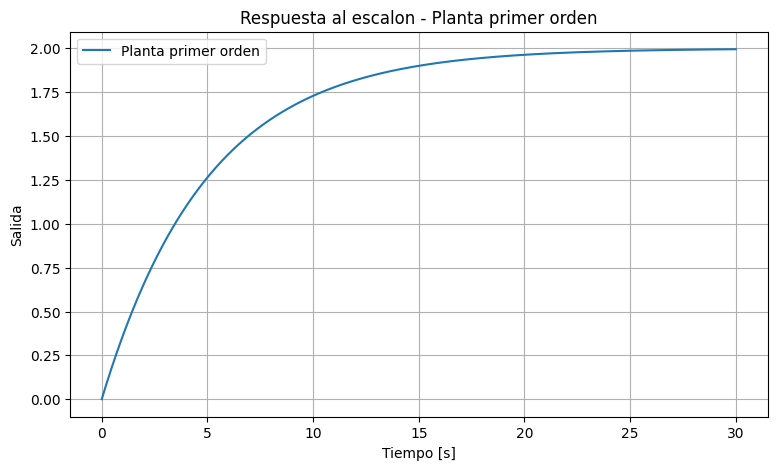

{'valor_final': 1.9950424956466895, 'valor_pico': 1.9950424956466895, 'sobrepico_%': 0.0, 'tiempo_subida_10_90': 10.87087087087087, 'tiempo_establecimiento': 19.00900900900901}


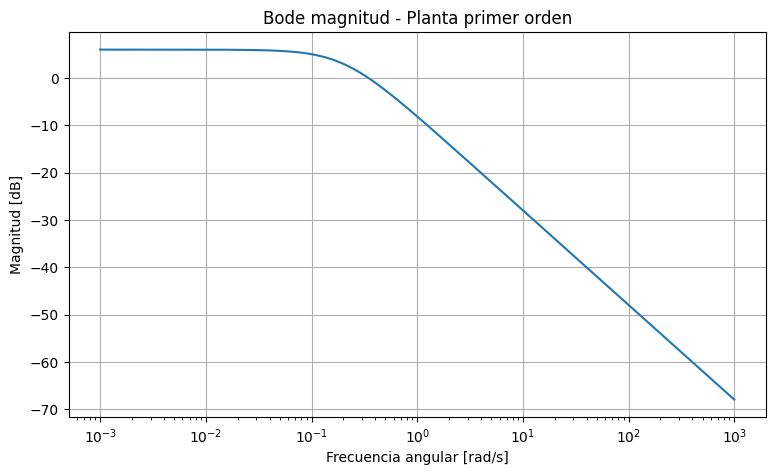

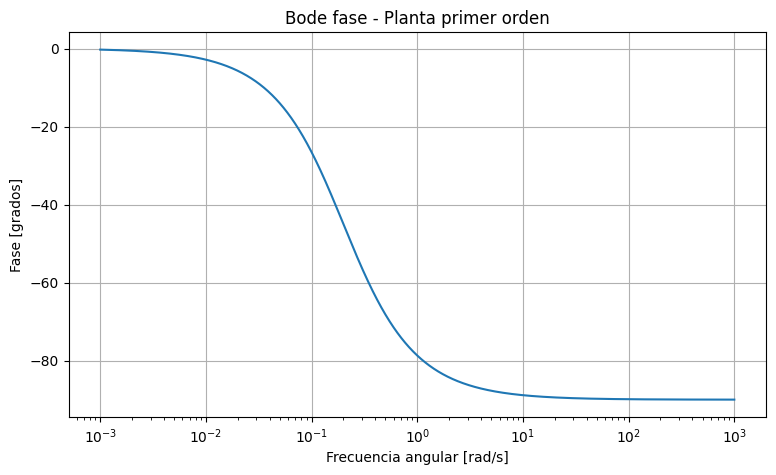

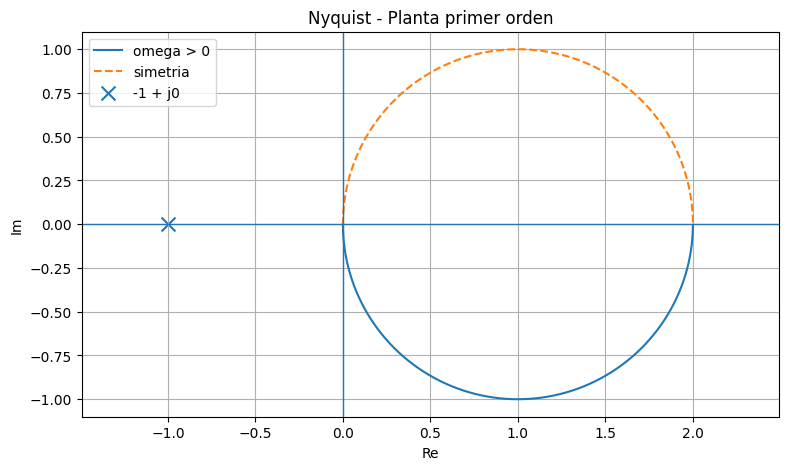

array([1.99995000e+00-0.00999975j, 1.99994965e+00-0.01003435j,
       1.99994931e+00-0.01006908j, ..., 8.11131878e-08-0.00040277j,
       8.05546694e-08-0.00040138j, 7.99999968e-08-0.0004j    ],
      shape=(4000,))

In [3]:
G1 = first_order(tau=5, K=2, name="Planta primer orden")
print_report(G1)
t, y = plot_step(G1, t_end=30)
print(step_info(t, y))
plot_bode(G1)
plot_nyquist(G1)

# 10. Ejemplo 2: segundo orden subamortiguado

$$G(s)=\frac{\omega_n^2}{s^2+2\zeta\omega_n s+\omega_n^2}$$

Segundo orden subamortiguado(s) = ( 
25) / (   2
1 x + 2.5 x + 25)

Polos:
[-1.25+4.84122918j -1.25-4.84122918j]

Ceros:
[]

Ganancia DC:
1.0

Estable:
True


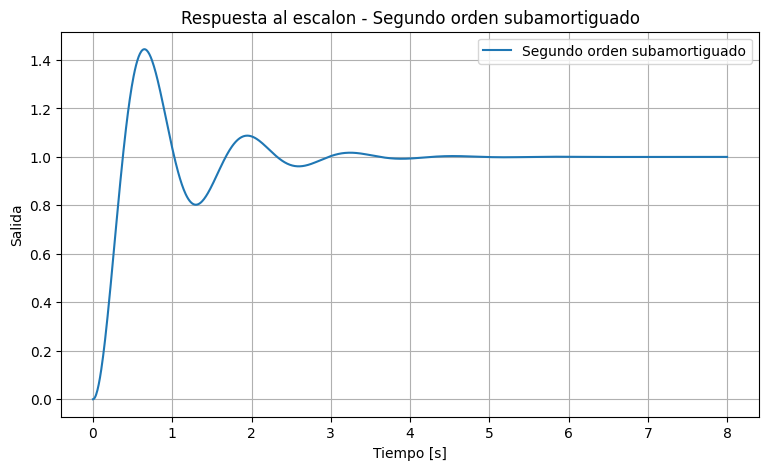

{'valor_final': 0.9999666015607864, 'valor_pico': 1.4443438020721704, 'sobrepico_%': 44.43920425120028, 'tiempo_subida_10_90': 0.25625625625625625, 'tiempo_establecimiento': 2.8268268268268266}


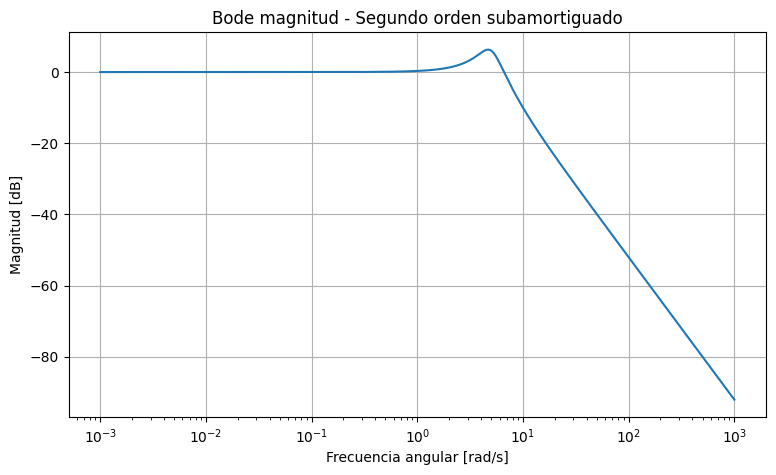

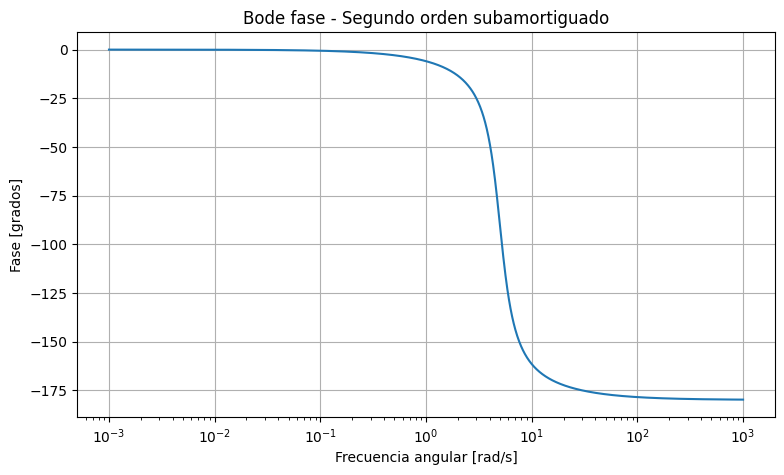

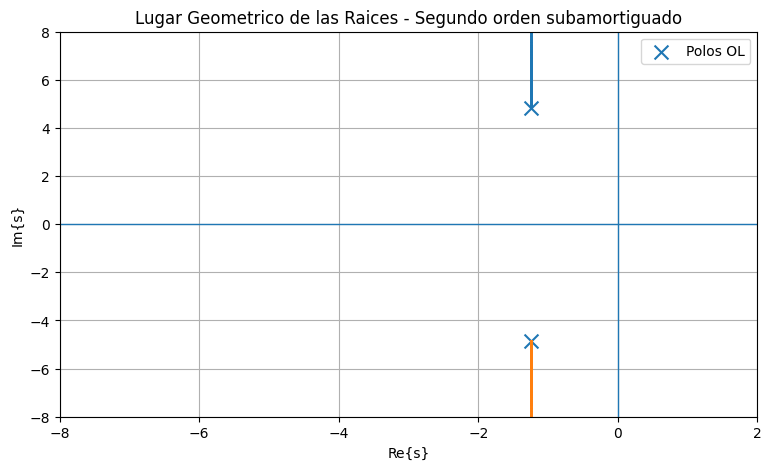

(array([1.00000000e-03, 1.01353371e-03, 1.02725058e-03, ...,
        9.73472311e+03, 9.86647004e+03, 1.00000000e+04], shape=(1200,)),
 array([[-1.25  +4.84381048j, -1.25  -4.84381048j],
        [-1.25  +4.84384541j, -1.25  -4.84384541j],
        [-1.25  +4.84388081j, -1.25  -4.84388081j],
        ...,
        [-1.25+493.34725616j, -1.25-493.34725616j],
        [-1.25+496.67412709j, -1.25-496.67412709j],
        [-1.25+500.02343695j, -1.25-500.02343695j]], shape=(1200, 2)))

In [4]:
G2 = second_order(wn=5, zeta=0.25, K=1, name="Segundo orden subamortiguado")
print_report(G2)
t, y = plot_step(G2, t_end=8)
print(step_info(t, y))
plot_bode(G2)
root_locus(G2, xlim=(-8, 2), ylim=(-8, 8))

# 11. Ejemplo 3: función de transferencia y lazo cerrado

$$G(s)=\frac{1}{s(s+2)}$$

Planta
G = 1/(s(s+2))(s) = ( 
1) / (   2
1 x + 2 x)

Polos:
[-2.  0.]

Ceros:
[]

Ganancia DC:
inf

Estable:
False
Lazo cerrado
T lazo cerrado(s) = ( 
1) / (   2
1 x + 2 x + 1)

Polos:
[-1. -1.]

Ceros:
[]

Ganancia DC:
1.0

Estable:
True


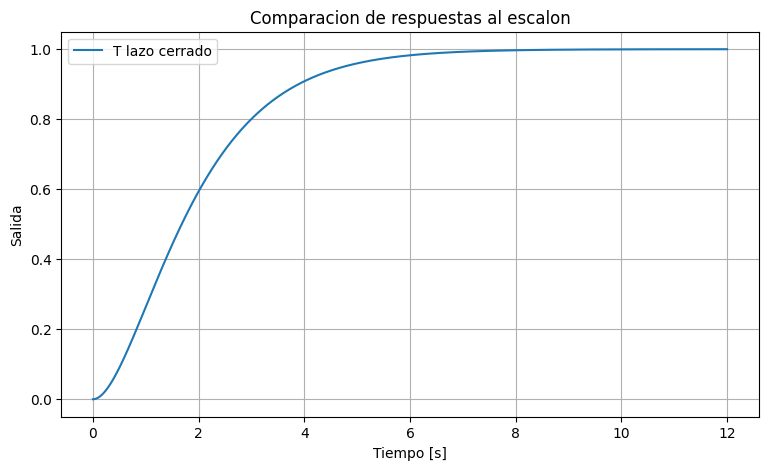

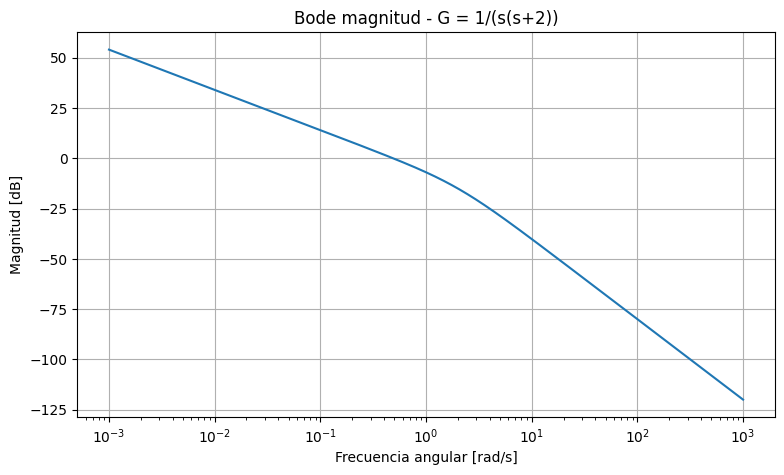

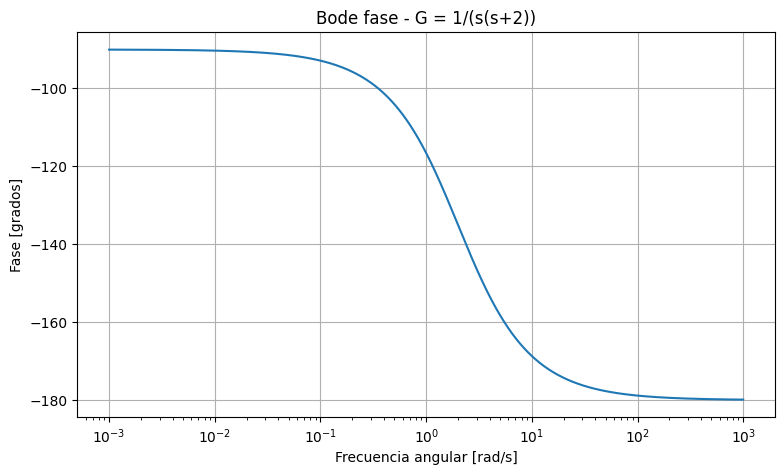

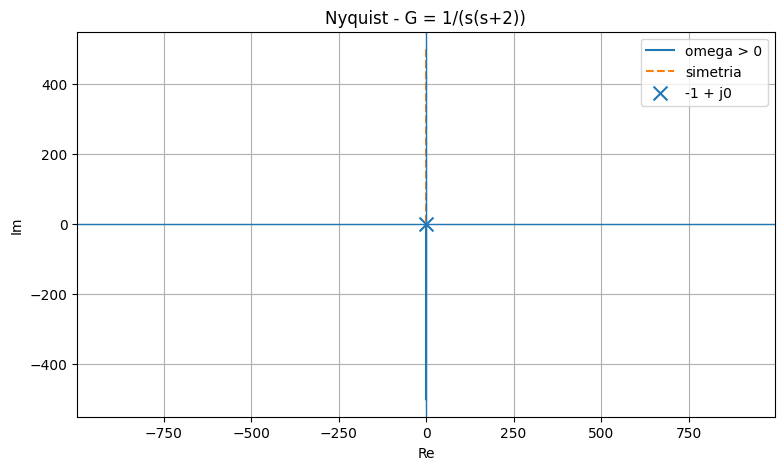

{'wcg_rad_s': 0.48553760761710935, 'PM_deg': 76.35436052031775, 'wcp_rad_s': None, 'GM': None, 'GM_dB': None}


In [6]:
G = TF([1], [1, 2, 0], name="G = 1/(s(s+2))")
T = feedback(G, name="T lazo cerrado")
print("Planta")
print_report(G)
print("Lazo cerrado")
print_report(T)
compare_step([T], t_end=12)
plot_bode(G)
plot_nyquist(G)
print(margins(G))

# 12. Ejemplo 4: espacio de estados

In [7]:
SS_G = G.to_ss(name="G en espacio de estados")
print(SS_G)
print("A ="); print(SS_G.A)
print("B ="); print(SS_G.B)
print("C ="); print(SS_G.C)
print("D ="); print(SS_G.D)
G_back = SS_G.to_tf(name="G recuperada desde SS")
print_report(G_back)

G en espacio de estados: SS continuo, n=2, m=1, p=1
A =
[[-2. -0.]
 [ 1.  0.]]
B =
[[1.]
 [0.]]
C =
[[0. 1.]]
D =
[[0.]]
G recuperada desde SS(s) = ( 
1) / (   2
1 x + 2 x)

Polos:
[-2.  0.]

Ceros:
[]

Ganancia DC:
inf

Estable:
False


# 13. Ejemplo 5: controlabilidad y observabilidad

In [8]:
print("Matriz de controlabilidad:")
print(SS_G.controllability_matrix())
print("Rango:", SS_G.controllability_rank())
print("Controlable:", SS_G.is_controllable())
print("Matriz de observabilidad:")
print(SS_G.observability_matrix())
print("Rango:", SS_G.observability_rank())
print("Observable:", SS_G.is_observable())
try:
    print("Gramiano de controlabilidad:")
    print(SS_G.gramian_controllability())
    print("Gramiano de observabilidad:")
    print(SS_G.gramian_observability())
except Exception as e:
    print("Gramianos no calculados:", e)

Matriz de controlabilidad:
[[ 1. -2.]
 [ 0.  1.]]
Rango: 2
Controlable: True
Matriz de observabilidad:
[[0. 1.]
 [1. 0.]]
Rango: 2
Observable: True
Gramiano de controlabilidad:
[[ 2.50000000e-01  1.25000000e-01]
 [ 1.25000000e-01 -5.62949953e+14]]
Gramiano de observabilidad:
[[-5.62949953e+14 -1.12589991e+15]
 [-1.12589991e+15 -2.25179981e+15]]


# 14. Ejemplo 6: Bode, Nyquist y márgenes

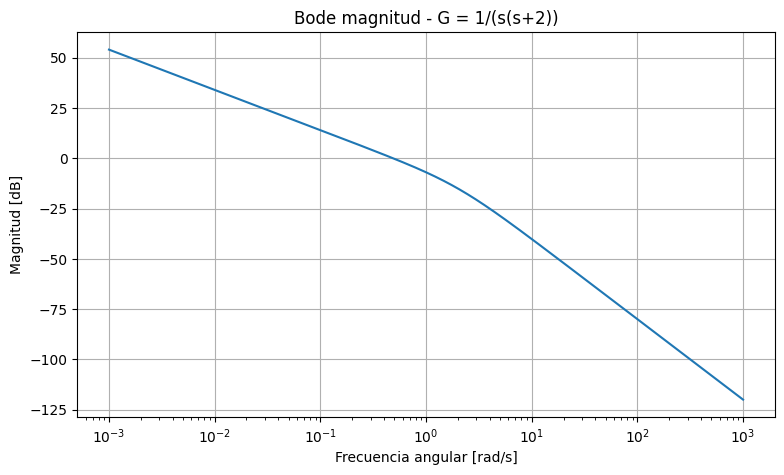

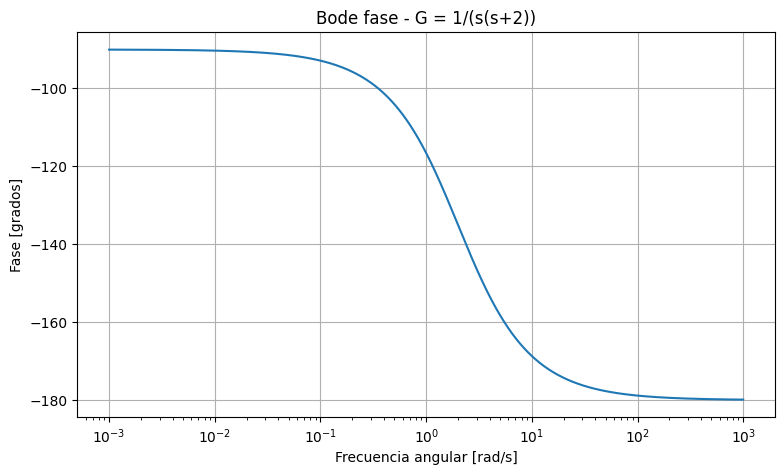

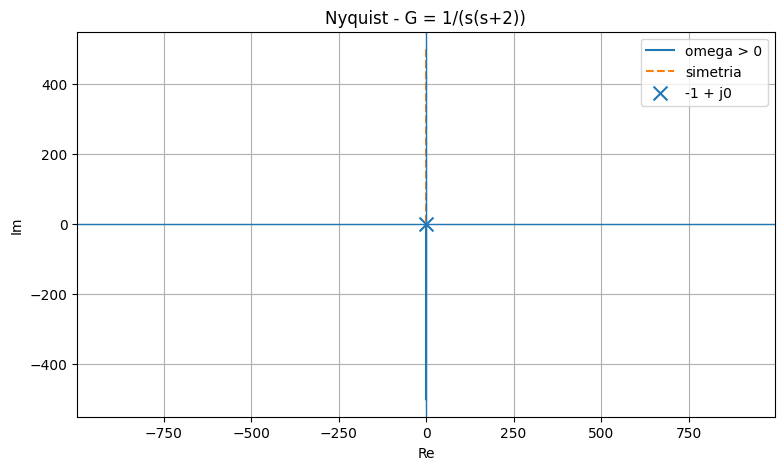

Margenes estimados:
{'wcg_rad_s': 0.48553760761710935, 'PM_deg': 76.35436052031775, 'wcp_rad_s': None, 'GM': None, 'GM_dB': None}


In [9]:
plot_bode(G)
plot_nyquist(G)
print("Margenes estimados:")
print(margins(G))

# 15. Ejemplo 7: root locus

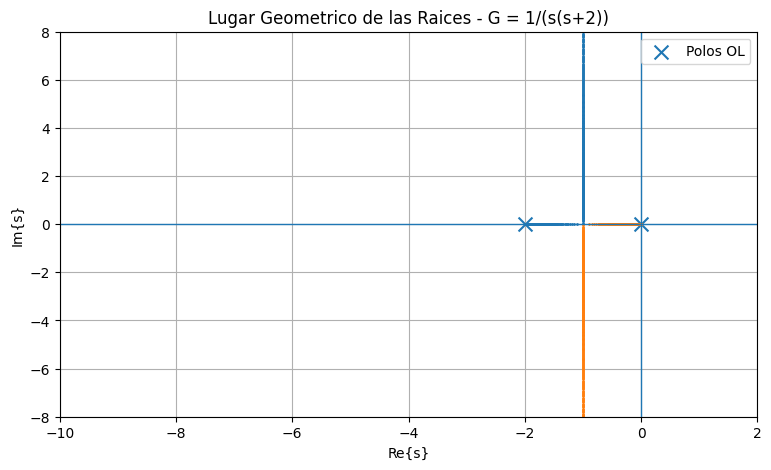

(array([1.00000000e-03, 1.01353371e-03, 1.02725058e-03, ...,
        9.73472311e+03, 9.86647004e+03, 1.00000000e+04], shape=(1200,)),
 array([[-1.99949987e+00 +0.j        , -5.00125063e-04 +0.j        ],
        [-1.99949310e+00 +0.j        , -5.06895327e-04 +0.j        ],
        [-1.99948624e+00 +0.j        , -5.13757265e-04 +0.j        ],
        ...,
        [-1.00000000e+00+98.65963261j, -1.00000000e+00-98.65963261j],
        [-1.00000000e+00+99.32507257j, -1.00000000e+00-99.32507257j],
        [-1.00000000e+00+99.99499987j, -1.00000000e+00-99.99499987j]],
       shape=(1200, 2)))

In [10]:
root_locus(G, xlim=(-10, 2), ylim=(-8, 8))

# 16. Ejemplo 8: compensador de adelanto

$$C_{lead}(s)=5\frac{s+2}{s+12}$$

In [ ]:
C_lead = lead(z=2, p=12, K=5, name="C_lead")
OL_lead = C_lead * G
OL_lead.name = "OL con adelanto"
CL_lead = feedback(OL_lead, name="CL con adelanto")
CL_base = feedback(G, name="CL base")
print_report(C_lead)
compare_bode([G, OL_lead])
root_locus(OL_lead, xlim=(-18, 2), ylim=(-10, 10))
compare_step([CL_base, CL_lead], t_end=12)

# 17. Ejemplo 9: compensador de atraso

$$C_{lag}(s)=\frac{s+0.5}{s+0.05}$$

In [ ]:
C_lag = lag(z=0.5, p=0.05, K=1, name="C_lag")
OL_lag = C_lag * G
OL_lag.name = "OL con atraso"
CL_lag = feedback(OL_lag, name="CL con atraso")
print_report(C_lag)
compare_bode([G, OL_lag], w=np.logspace(-3, 3, 3000))
root_locus(OL_lag, xlim=(-10, 2), ylim=(-8, 8))
compare_step([CL_base, CL_lag], t_end=40)

# 18. Ejemplo 10: compensador adelanto-atraso

$$C(s)=3\frac{(s+2)(s+0.5)}{(s+12)(s+0.05)}$$

In [ ]:
C_ll = lead_lag(z_lead=2, p_lead=12, z_lag=0.5, p_lag=0.05, K=3, name="C_lead_lag")
OL_ll = C_ll * G
OL_ll.name = "OL lead-lag"
CL_ll = feedback(OL_ll, name="CL lead-lag")
print_report(C_ll)
compare_bode([G, OL_lead, OL_lag, OL_ll], w=np.logspace(-3, 3, 3000))
root_locus(OL_ll, xlim=(-18, 2), ylim=(-10, 10))
compare_step([CL_base, CL_lead, CL_lag, CL_ll], t_end=35)

# 19. Ejemplo 11: discretización

$$G(s) \rightarrow G(z)$$ con $T_s=0.05s$.

In [ ]:
Ts = 0.05
Gd = discretize_tf(G, dt=Ts, method="zoh", name="G discreta ZOH")
print_report(Gd)
Td = feedback(Gd, name="T discreta")
print_report(Td)
plot_step(Td, n=200)
plot_bode(Gd, w=np.linspace(0.01, np.pi/Ts, 2000))

# 20. Pruebas internas mínimas

Estas pruebas verifican creación de sistemas, feedback, conversión TF/SS, discretización y rangos básicos.

In [ ]:
def run_basic_tests():
    tests = {}
    Gt = TF([1], [1, 2, 1], name="TestG")
    tests["crear_TF"] = isinstance(Gt, TF)
    Tt = feedback(Gt)
    tests["feedback_TF"] = isinstance(Tt, TF)
    SSt = Gt.to_ss()
    tests["TF_to_SS"] = isinstance(SSt, SS)
    Gt2 = SSt.to_tf()
    tests["SS_to_TF"] = isinstance(Gt2, TF)
    tests["controlabilidad_rank"] = SSt.controllability_rank() == SSt.A.shape[0]
    tests["observabilidad_rank"] = SSt.observability_rank() == SSt.A.shape[0]
    Gdt = discretize_tf(Gt, dt=0.1)
    tests["discretizacion"] = Gdt.is_discrete
    for k, v in tests.items():
        print(f"{k}: {'OK' if v else 'FALLO'}")
run_basic_tests()

# 21. Hoja de ruta para hacerlo crecer

## Etapa 1: robustez del core

- mejorar `minreal`;
- agregar tolerancias configurables;
- interpolar márgenes;
- advertir sobre mal condicionamiento;
- escalar polinomios automáticamente;
- evitar TF para órdenes altos.

## Etapa 2: control moderno

- colocación de polos;
- LQR;
- observadores;
- filtro de Kalman;
- estimadores.

## Etapa 3: robustez numérica

- representación interna preferente en espacio de estados;
- balanceo de realizaciones;
- gramianos robustos;
- reducción de modelos;
- uso opcional de `slycot`;
- integración opcional con `python-control`.

## Etapa 4: control digital

- Tustin con prewarping;
- diseño digital directo;
- análisis en plano z;
- cuantización;
- saturaciones.

## Etapa 5: plataforma

- API modular;
- documentación;
- notebooks de validación;
- tests automáticos;
- exportación/importación;
- interfaz gráfica;
- simulación por bloques.

# 22. Conclusión

Este notebook construye una semilla de plataforma de control.

No pretende ocultar la matemática, sino exponerla. No pretende ser MATLAB, sino mostrar cómo se empieza a construir algo en esa dirección.

La clave conceptual es:

$$
G_{OL}(s)=G_c(s)G_p(s)
$$

$$
G_{CL}(s)=\frac{G_{OL}(s)}{1+G_{OL}(s)}
$$

Y la clave computacional moderna es:

$$
\dot{x}=Ax+Bu
$$

$$
y=Cx+Du
$$

El crecimiento natural del proyecto es migrar progresivamente desde una herramienta didáctica basada en funciones de transferencia hacia un core numérico robusto basado en espacio de estados, álgebra lineal y validaciones sistemáticas.